# **Kütüphanelerin Eklenmesi**

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

sns.set_theme(style = "whitegrid")
import warnings
warnings.filterwarnings("ignore")

# **Veri Setini Oluşturma (Aşağıdaki Kodu Çalıştırmaya Gerek Yok.)**


IMDb'den aldığım veri setleri olan "title.episode.tsv.gz" (dizi veya filmlerin bölüm içerikleri var) ve "title.ratings.tsv.gz" (ratingler bu veri setinde) birleştirip istediğim dizinin verilerini ayıkladıktan sonra kendi veri setimi oluşturdum. Bu veri setini oluşturmak için gereken kod aşağıda bulunuyor. Çalıştırılmasına gerek yok veri setini GitHub üzerinden çekeceğiz.

**Veri seti hangi problem için oluşturulmuştur?**

*    Veri seti, One Piece anime bölümlerinin IMDB puanlarının, sezon/bölüm ilerlemesi ve oy sayısının analizi ile rating tahminlemesi yapabilmek için oluşturuldu.

**Veri setinde kaç gözlem vardır?**

*   Toplam 1155 adet gözlem bulunmakta.

**Kaç özellik bulunmaktadır?**

*   5 adet özellik bulunmakta bunlar: Episode_ID, Season, Episode, Rating, Votes

**Tahmin edilmek istenen hedef değişken nedir?**

*   Hedef değişkenimiz "Rating"tir.

**Problem türü nedir?**

*   Hedefimiz (Rating) sürekli olarak sayısal değer olduğu için bu bir **Regresyon** problemi.

In [80]:
episodes_file = "title.episode.tsv.gz"
ratings_file = "title.ratings.tsv.gz"

print("Bölüm ile ilgili veriler okunuyor")
df_episodes = pd.read_csv(episodes_file, sep="\t", usecols=["tconst", "parentTconst", "seasonNumber", "episodeNumber"], low_memory=False)

print("One Piece ile ilgili veriler okunuyor")
op_episodes = df_episodes[df_episodes["parentTconst"] == "tt0388629"].copy() #One Piece IMDb ID'si -> tt0388629

print("One Piece'e ait rating verileri okunuyor")
df_ratings = pd.read_csv(ratings_file, sep="\t", low_memory=False)

print("Tablolar bölüm ID'lerine göre birleştiriliyor")
op_data = pd.merge(op_episodes, df_ratings, on="tconst", how="inner")

print("Veriler temizleniyor")
#Boş satırları temizler
op_data = op_data[op_data["seasonNumber"] != "\\N"]
op_data = op_data[op_data["episodeNumber"] != "\\N"]

#Metin olanları integer'a çevirme
op_data["seasonNumber"] = pd.to_numeric(op_data["seasonNumber"])
op_data["episodeNumber"] = pd.to_numeric(op_data["episodeNumber"])

#Verileri sıralama
op_data = op_data.sort_values(by=["seasonNumber", "episodeNumber"])

#Verilen tanımları sadeleştirme
op_data = op_data.rename(columns={
    "tconst": "Episode_ID",
    "seasonNumber": "Season",
    "episodeNumber": "Episode",
    "averageRating": "Rating",
    "numVotes": "Votes"
})
op_data = op_data.drop(columns=["parentTconst"])

output_file = "one_piece_ratings_dataset.csv"
op_data['Episode_ID'] = range(1, len(op_data) + 1) #Burada ID'ler tt1234567 türünden bölüm numarasına çeviriliyor.
op_data.to_csv(output_file, index=False)
print("Veri seti oluşturuldu")

# **Verinin Analizi**

--- İlk 5 Satır---



,Episode_ID,Season,Episode,Rating,Votes
0,1,1,1,8.4,41983
1,2,1,2,8.4,25692
2,3,1,3,8.0,8601
3,4,1,4,8.3,7400
4,5,1,5,7.4,5308



--- Veri Tipleri ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1155 entries, 0 to 1154
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Episode_ID  1155 non-null   int64  
 1   Season      1155 non-null   int64  
 2   Episode     1155 non-null   int64  
 3   Rating      1155 non-null   float64
 4   Votes       1155 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 45.2 KB

--- Eksik Veri Kontrolü ---

Episode_ID    0
Season        0
Episode       0
Rating        0
Votes         0
dtype: int64

--- Temel İstatistikler ---



,Episode_ID,Season,Episode,Rating,Votes
count,1155.000000,1155.0,1155.000000,1155.000000,1155.000000
mean,578.000000,1.0,578.000000,8.107359,3552.570563
std,333.564087,0.0,333.564087,0.886900,7493.780555
min,1.000000,1.0,1.000000,5.200000,726.000000
25%,289.500000,1.0,289.500000,7.500000,1120.500000
50%,578.000000,1.0,578.000000,8.000000,1685.000000
75%,866.500000,1.0,866.500000,8.900000,3284.000000
max,1155.000000,1.0,1155.000000,9.800000,102327.000000


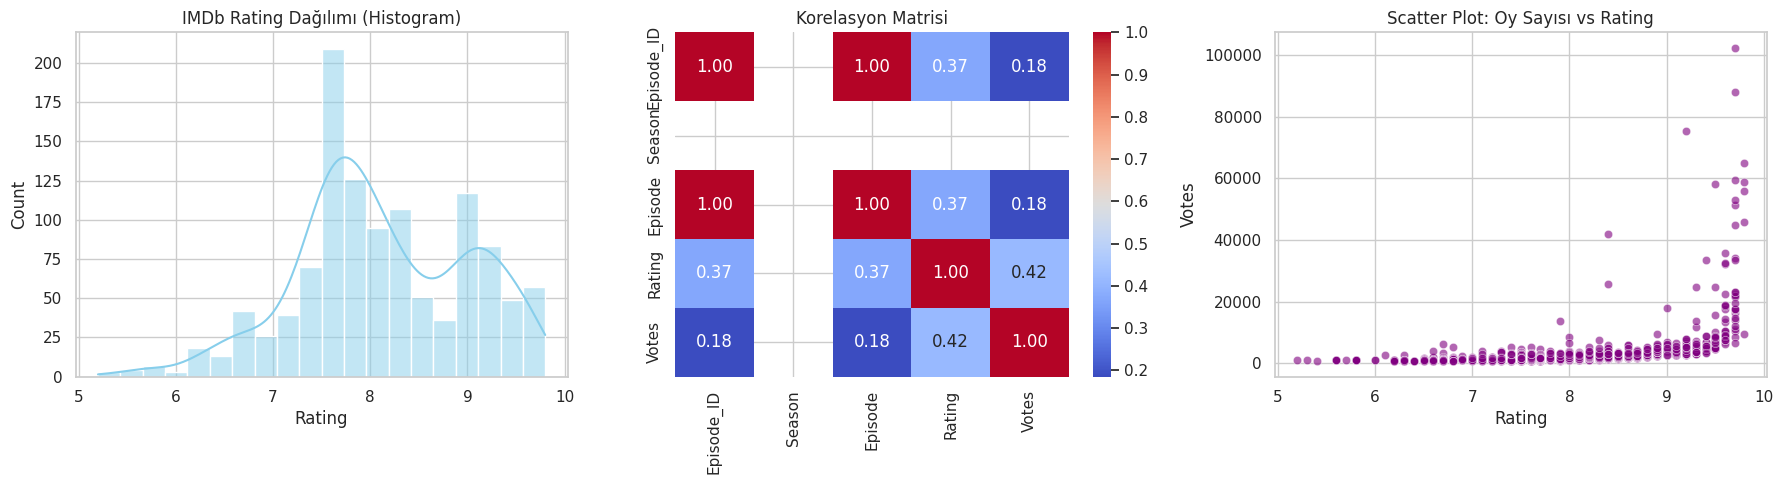

In [81]:
#Veri setimiz
url = "https://raw.githubusercontent.com/HsHappy/one-piece-imdb-regression-project/refs/heads/main/one_piece_ratings_dataset.csv"
df = pd.read_csv(url)

print("--- İlk 5 Satır---\n")
display(df.head())

print("\n--- Veri Tipleri ---\n")
df.info()

print("\n--- Eksik Veri Kontrolü ---\n")
print(df.isnull().sum())

print("\n--- Temel İstatistikler ---\n")
display(df.describe())

plt.figure(figsize=(18, 5))

#Histogram
plt.subplot(1, 3, 1)
sns.histplot(df["Rating"], bins=20, kde=True, color="skyblue")
plt.title("IMDb Rating Dağılımı (Histogram)")

#Korelasyon Matrisi
plt.subplot(1, 3, 2)
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelasyon Matrisi")

#Scatter Plot
plt.subplot(1, 3, 3)
sns.scatterplot(x="Rating", y="Votes", data=df, alpha=0.6, color="purple")
plt.title("Scatter Plot: Oy Sayısı vs Rating")

plt.tight_layout()
plt.show()

# **Veri Ön İşleme**

In [82]:
df = df.dropna()

#Episode_ID unique key olduğundan modele katılmıyor.
X = df[["Season", "Episode", "Votes"]]
y = df["Rating"]

#Eğitim ve Test setlerine bölme
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **Model Oluşturma ve Değerlendirme**

In [83]:
def evaluate_model(y_true, y_pred, model_name):
  #Regresyon hatalarının hesaplandığı yer
  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_true, y_pred)

  print(f"--- {model_name} Performansı ---")
  print(f"MAE: {mae: .4f}")
  print(f"MSE: {mse: .4f}")
  print(f"RMSE: {rmse: .4f}")
  print(f"R²: {r2: .4f}\n")

#Lineer Regresyon
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)
evaluate_model(y_test, lr_preds, "Lineer Regresyon")

#Ridge Regresyon (ölçeklenmiş olduğundan X_train_scaled kullanıyoruz)
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
ridge_preds = ridge_model.predict(X_test_scaled)
evaluate_model(y_test, ridge_preds, "Ridge Regresyon")

#Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)
evaluate_model(y_test, dt_preds, "Decision Tree Regressor")

--- Lineer Regresyon Performansı ---
MAE:  0.5832
MSE:  0.5330
RMSE:  0.7301
R²:  0.2110

--- Ridge Regresyon Performansı ---
MAE:  0.5832
MSE:  0.5330
RMSE:  0.7301
R²:  0.2109

--- Decision Tree Regressor Performansı ---
MAE:  0.2104
MSE:  0.1206
RMSE:  0.3473
R²:  0.8214



# **Cross Validation**

In [84]:
print("--- K-Fold Cross Validation (K = 5) Sonuçları ---")

kf = KFold(n_splits=5, shuffle=True, random_state=42)

#Lineer Regresyon CV (Pipeline ile leakage önlenir)
pipeline_lr = Pipeline([("scaler", StandardScaler()), ("lr", LinearRegression())])
cv_scores_lr = cross_val_score(pipeline_lr, X, y, cv=kf, scoring="neg_mean_squared_error")
cv_rmse_lr = np.sqrt(-cv_scores_lr)
print(f"Lineer Regresyon Ortalama RMSE: {cv_rmse_lr.mean(): .4f}")

#Ridge Regresyon CV (Pipeline ile leakage önlenir)
pipeline_ridge = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=0.1))])
cv_scores_ridge = cross_val_score(pipeline_ridge, X, y, cv=kf, scoring="neg_mean_squared_error")
cv_rmse_ridge = np.sqrt(-cv_scores_ridge)
print(f"Ridge Regresyon Ortalama RMSE: {cv_rmse_ridge.mean(): .4f}")

#Decision Tree Regressor CV
dt_model_cv = DecisionTreeRegressor(random_state=42)
cv_scores_dt = cross_val_score(dt_model_cv, X, y, cv=kf, scoring="neg_mean_squared_error")
cv_rmse_dt = np.sqrt(-cv_scores_dt)
print(f"Decision Tree Regressor Ortalama RMSE: {cv_rmse_dt.mean(): .4f}")

--- K-Fold Cross Validation (K = 5) Sonuçları ---
Lineer Regresyon Ortalama RMSE:  0.7669
Ridge Regresyon Ortalama RMSE:  0.7669
Decision Tree Regressor Ortalama RMSE:  0.3656


# **Hiperparametre Optimizasyonu**

In [85]:
print("--- Grid Search ile Hiperparametre Optimizasyonu ---")

#Ridge Regresyon
ridge_param_grid = {"alpha": [0.01, 0.1, 1.0, 10.0, 100.0, 500.0]}

grid_search_ridge = GridSearchCV(estimator = Ridge(),
                                 param_grid = ridge_param_grid,
                                 cv = 5,
                                 scoring = "neg_mean_squared_error")

grid_search_ridge.fit(X_train_scaled, y_train)

print(f"Ridge En İyi Parametreler: {grid_search_ridge.best_params_}\n")
best_ridge_model = grid_search_ridge.best_estimator_

best_ridge_preds = best_ridge_model.predict(X_test_scaled)
evaluate_model(y_test, best_ridge_preds, "Optimize Edilmiş Ridge Regresyonu")

#Decision Tree Regressor
dt_param_grid = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 5, 10]
}

grid_search_dt = GridSearchCV(DecisionTreeRegressor(random_state=42),
                           param_grid = dt_param_grid,
                           cv = 5,
                           scoring = "neg_mean_squared_error",
                           n_jobs = -1)

grid_search_dt.fit(X_train, y_train)

print(f"Decision Tree En İyi Parametreler: {grid_search_dt.best_params_}\n")
best_dt_model = grid_search_dt.best_estimator_

best_dt_preds = best_dt_model.predict(X_test)
evaluate_model(y_test, best_dt_preds, "Optimize Edilmiş Decision Tree Regressor")

--- Grid Search ile Hiperparametre Optimizasyonu ---
Ridge En İyi Parametreler: {'alpha': 10.0}

--- Optimize Edilmiş Ridge Regresyonu Performansı ---
MAE:  0.5835
MSE:  0.5334
RMSE:  0.7304
R²:  0.2103

Decision Tree En İyi Parametreler: {'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 2}

--- Optimize Edilmiş Decision Tree Regressor Performansı ---
MAE:  0.2117
MSE:  0.1049
RMSE:  0.3238
R²:  0.8447



# **Sonuçların Yorumlanması**

**Hangi model daha iyi performans göstermiştir?**

*   Çalışmada açık ara en iyi performansı Decision Tree Regressor modeli göstermiştir. Doğrusal modeller reyting değişimlerinin ancak %21'ini açıklayabilirken (R²: 0.2110), Decision Tree modeli optimize edildikten sonra %84.47 (R²: 0.8447) gibi oldukça yüksek bir açıklanabilirlik oranına ve en düşük hata payına (RMSE: 0.3238) ulaşmıştır.

**Model overfitting yapıyor mu?**

*   Doğrusal modellerde overfitting görülmemiştir. Decision Tree modelinin varsayılan hali ise yapısı gereği ezberlemeye (overfitting) çok müsaittir. Ancak GridSearchCV ile belirli hiperparametrelere sınırlandırmalar getirildi. Bu sayede körü körüne ezberlemeye engel olundu. Cross Validation ortalama RMSE skorunun (0.3656) test seti RMSE skoruna (0.3238) oldukça yakın çıkması, modelin overfit yapmadığını ve yeni verilere başarıyla genellenebildiğini  kanıtlamaktadır.

**Veri setinin büyüklüğü model performansını nasıl etkileyebilir?**

*   Veri setimizde yer alan 1155 adet gözlem, uygulanan temel makine öğrenmesi algoritmalarını eğitmek için yeterli bir büyüklüktedir. Veri seti büyüdükçe algoritmaların varyansı düşer, farklı senaryoları öğrenme kapasitesi artar ve overfitting riski daha da azalır.

**Daha iyi sonuç almak için ne yapılabilir?**

*   Modele sadece sezon ve bölüm numarası değil; bölümün "Filler" (doldurma) olup olmadığı, mangada hangi hikaye örgüsüne ait olduğu veya animasyon stüdyosunun o bölümdeki bütçesi/yönetmeni gibi yeni özellikler eklenebilir.
*   Tek bir Karar Ağacı yerine, Random Forest, XGBoost veya LightGBM kullanılarak hata oranları çok daha fazla bir şekilde düşürülebilir.
*   Çok düşük oylanan veya aşırı yüksek oylanan bölümler analiz edip veri seti bu değerlerden arındırılabilir.



